# Lab 2: Robot Motion Planning and Control

## Introduction
This laboratory work investigates the modeling, kinematic analysis, and trajectory planning of the Panda manipulator using the Robotics Toolbox for Python.

Modern robotic systems require accurate modeling of motion and dynamics in order to perform tasks efficiently and safely. This lab integrates forward kinematics, inverse kinematics, and trajectory generation to simulate realistic robotic motion.

The Panda robot model is used here because it was the selected manipulator in Laboratory Work No. 1.

## Objectives

The main objectives of this laboratory work are:

- Load and configure the Panda robot model
- Define its kinematic and dynamic parameters
- Select a valid initial joint configuration
- Solve the forward kinematics problem
- Construct the workspace of the manipulator
- Solve the inverse kinematics problem for a target point
- Plan trajectories using three different methods
- Analyze motion using position, velocity, and acceleration plots

In [4]:
!pip install spatialmath-python roboticstoolbox-python

In [5]:
!pip uninstall -y numpy roboticstoolbox-python spatialmath-python
!pip install "numpy<2" spatialmath-python roboticstoolbox-python

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: roboticstoolbox-python 1.1.1
Uninstalling roboticstoolbox-python-1.1.1:
  Successfully uninstalled roboticstoolbox-python-1.1.1
Found existing installation: spatialmath-python 1.1.16
Uninstalling spatialmath-python-1.1.16:
  Successfully uninstalled spatialmath-python-1.1.16
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 799.1 kB/s eta 0:00:00
  Using cached spatialmath_python-1.1.16-py3-none-any.whl.metadata (18 kB)
  Using cached roboticstoolbox_python-1.1.1-cp312-cp312-linux_x86_64.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 44.1 MB/s eta 0:00:00
Using cached spatialmath_python-1.1.16-py3-none-any.whl (193 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires

In [1]:
# import libs
import pandas as pd
from math import pi
import numpy as np
import roboticstoolbox as rtb
import spatialmath.base as sb
import matplotlib.pyplot as plt


## Robot Model and DH Representation

The Panda manipulator is modeled using the Denavit–Hartenberg (DH) convention.

Each link is defined by four parameters:

- Link length: $a_i$
- Link offset: $d_i$
- Link twist: $\alpha_i$
- Joint angle: $\theta_i$

These parameters define the geometric relationship between consecutive links and allow the computation of transformations along the kinematic chain.

In [2]:
# Load model Panda as in Lab 1
robot = rtb.models.DH.Panda()

In [3]:
#show parametrs & DH
print(robot)


DHRobot: Panda (by Franka Emika), 7 joints (RRRRRRR), dynamics, geometry, modified DH parameters
┌─────────┬────────┬─────┬───────┬─────────┬────────┐
│  aⱼ₋₁   │  ⍺ⱼ₋₁  │ θⱼ  │  dⱼ   │   q⁻    │   q⁺   │
├─────────┼────────┼─────┼───────┼─────────┼────────┤
│     0.0 │   0.0° │  q1 │ 0.333 │ -166.0° │ 166.0° │
│     0.0 │ -90.0° │  q2 │   0.0 │ -101.0° │ 101.0° │
│     0.0 │  90.0° │  q3 │ 0.316 │ -166.0° │ 166.0° │
│  0.0825 │  90.0° │  q4 │   0.0 │ -176.0° │  -4.0° │
│ -0.0825 │ -90.0° │  q5 │ 0.384 │ -166.0° │ 166.0° │
│     0.0 │  90.0° │  q6 │   0.0 │   -1.0° │ 215.0° │
│   0.088 │  90.0° │  q7 │ 0.107 │ -166.0° │ 166.0° │
└─────────┴────────┴─────┴───────┴─────────┴────────┘

┌──────┬───────────────────────────────────────┐
│ tool │ t = 0, 0, 0.1; rpy/xyz = -45°, 0°, 0° │
└──────┴───────────────────────────────────────┘

┌──────┬─────┬────────┬─────┬───────┬─────┬───────┬──────┐
│ name │ q0  │ q1     │ q2  │ q3    │ q4  │ q5    │ q6   │
├──────┼─────┼────────┼─────┼───────┼─────

## Robot Dynamics

The dynamic behavior of the manipulator is described by:

$$
\tau = M(q)\ddot{q} + C(q, \dot{q})\dot{q} + G(q) + F
$$


- mass :


In [4]:
# Masses from Lab 1
robot.links[0].m = 5
robot.links[1].m = 2.34471
robot.links[2].m = 2.36414
robot.links[3].m = 2.38050
robot.links[4].m = 2.42754
robot.links[5].m = 3.49611
robot.links[6].m = 1.46736

- Centers of mass :


In [5]:
# Centers of mass from Lab 1
robot.links[0].r = [ 0.00033, -0.02204, -0.04762]
robot.links[1].r = [ 0.00038, -0.09211,  0.01908]
robot.links[2].r = [ 0.05152,  0.01696, -0.02971]
robot.links[3].r = [-0.05113,  0.05825,  0.01698]
robot.links[4].r = [-0.00005,  0.03730, -0.09280]
robot.links[5].r = [ 0.06572, -0.00371,  0.00153]
robot.links[6].r = [ 0.00089, -0.00044,  0.05491]

- Inertia tensors :

In [6]:
# Inertia tensors from Lab 1
robot.links[0].I = [0.7,   0.71,  0.0091, -0.00014,  0.019,    0.0068]
robot.links[1].I = [0.008, 0.028, 0.026,  -0.0039,   0.0007,   0.01]
robot.links[2].I = [0.037, 0.036, 0.011,  -0.0048,  -0.013,   -0.011]
robot.links[3].I = [0.026, 0.02,  0.028,   0.0078,   0.0086,  -0.0013]
robot.links[4].I = [0.036, 0.029, 0.0086, -0.0021,   0.00023, -0.004]
robot.links[5].I = [0.002, 0.0044,0.0054,  0.00011,  0.00034, -0.0012]
robot.links[6].I = [0.013, 0.01,  0.0048, -0.00043, -0.00074, -0.0012]

- Motors inertias :

In [7]:
# Motor inertias from Lab 1
robot.links[0].Jm = 2e-4
robot.links[1].Jm = 2e-4
robot.links[2].Jm = 1.5e-4
robot.links[3].Jm = 1.5e-4
robot.links[4].Jm = 1e-4
robot.links[5].Jm = 1e-4
robot.links[6].Jm = 5e-5

- Friction coefficients :

In [8]:
# Viscous friction coefficients from Lab 1
robot.links[0].B = 0.7
robot.links[1].B = 1.9
robot.links[2].B = 1.5
robot.links[3].B = 1.7
robot.links[4].B = 1.7
robot.links[5].B = 1.2
robot.links[6].B = 1.4

- Coulomb friction coefficients :

In [9]:
# Coulomb friction coefficients from Lab 1
robot.links[0].Tc = [0.2, -0.2]
robot.links[1].Tc = [0.3, -0.3]
robot.links[2].Tc = [0.25, -0.25]
robot.links[3].Tc = [0.35, -0.35]
robot.links[4].Tc = [0.2, -0.2]
robot.links[5].Tc = [0.15, -0.15]
robot.links[6].Tc = [0.1, -0.1]

- Gear ratios :

In [10]:
# Gear ratios from Lab 1
robot.links[0].G = 1
robot.links[1].G = 1
robot.links[2].G = 1
robot.links[3].G = 1
robot.links[4].G = 1
robot.links[5].G = 1
robot.links[6].G = 1

- Joints Limits :


In [11]:
# Joint limits from Lab 1
robot.links[0].qlim = [-2.9, 2.9]
robot.links[1].qlim = [-1.8, 1.8]
robot.links[2].qlim = [-2.9, 2.9]
robot.links[3].qlim = [-3.1, -0.07]
robot.links[4].qlim = [-2.9, 2.9]
robot.links[5].qlim = [-0.018, 3.8]
robot.links[6].qlim = [-2.9, 2.9]

## Initial Configuration

An arbitrary initial joint configuration is selected:

$$
q_{start} = [q_1, q_2, q_3, q_4, q_5, q_6, q_7]
$$

The configuration is chosen to avoid singularities and ensure a valid starting pose for motion planning.

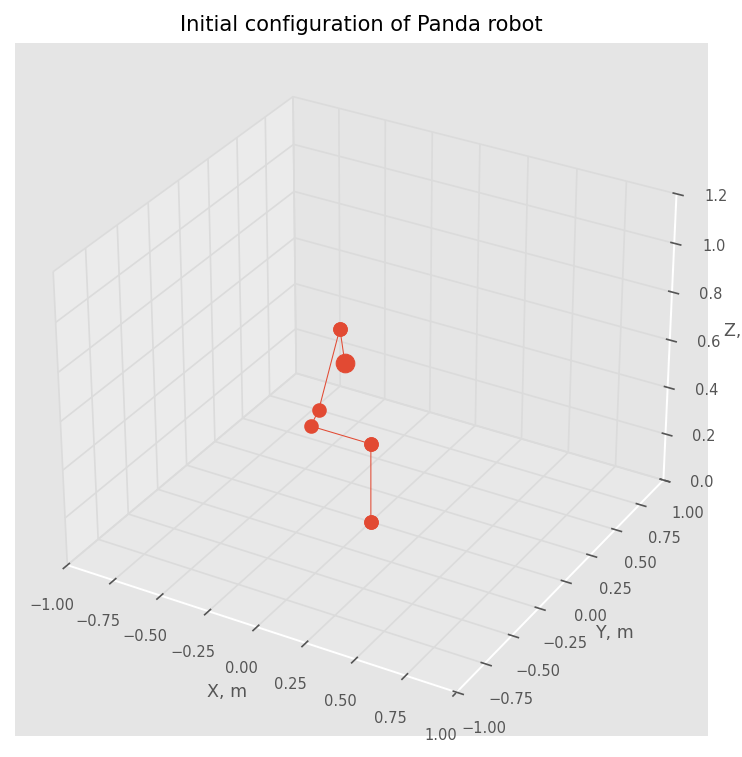

In [19]:
q_start=[0, -np.pi/2, np.pi/3, -np.pi/2, np.pi/4, 0 , 0]
# Plot robot configuration manually using joint coordinates
T_all = robot.fkine_all(q_start)

xs = [0]
ys = [0]
zs = [0]

for T in T_all:
    xs.append(T.t[0])
    ys.append(T.t[1])
    zs.append(T.t[2])

fig = plt.figure(figsize=(7, 6), dpi=150)
ax = fig.add_subplot(111, projection='3d')

ax.plot(xs, ys, zs, marker='o')
ax.scatter(xs[-1], ys[-1], zs[-1], s=80)

ax.set_title("Initial configuration of Panda robot")
ax.set_xlabel("X, m")
ax.set_ylabel("Y, m")
ax.set_zlabel("Z, m")

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(0, 1.2)

plt.show()


## Forward Kinematics

Forward kinematics determines the position and orientation of the end-effector based on joint variables.

The homogeneous transformation matrix between two consecutive links is defined as:

$$
T_i^{i-1} =
\begin{bmatrix}
\cos\theta_i & -\sin\theta_i \cos\alpha_i & \sin\theta_i \sin\alpha_i & a_i \cos\theta_i \\
\sin\theta_i & \cos\theta_i \cos\alpha_i & -\cos\theta_i \sin\alpha_i & a_i \sin\theta_i \\
0 & \sin\alpha_i & \cos\alpha_i & d_i \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

The overall transformation from base to end-effector is:

$$
T = \prod_{i=1}^{n} T_i^{i-1}
$$

This matrix fully describes the pose (position and orientation) of the robot end-effector in Cartesian space.

In [20]:
#FK for start point
T_start=robot.fkine(q_start)
print(T_start)

   0         1         0        -0.3363    
   0.5       0        -0.866     0.2532    
  -0.866     0        -0.5       0.4074    
   0         0         0         1         



## Workspace Construction

The workspace represents all reachable positions of the end-effector.


In [21]:
n=20 # number of sample in each statue
i=0 # for count
move=[np.linspace(robot.links[i].qlim[0],robot.links[i].qlim[1],n) for i in range(3)] # make samples for the first 3 joint
pose=np.zeros([3,n**3]) # for save the pos


In [22]:
# Studying all cases and calculating forward kinematics
for q1 in move[0]:
    for q2 in move[1]:
        for q3 in move[2]:
            # Panda has 7 joints, so the remaining four joints are fixed
            Tt = robot.fkine([q1, q2, q3, -np.pi/2, 0, np.pi/2, 0])
            for j in range(3):
                pose[j][i] = Tt.t[j] # position in each case
            i += 1

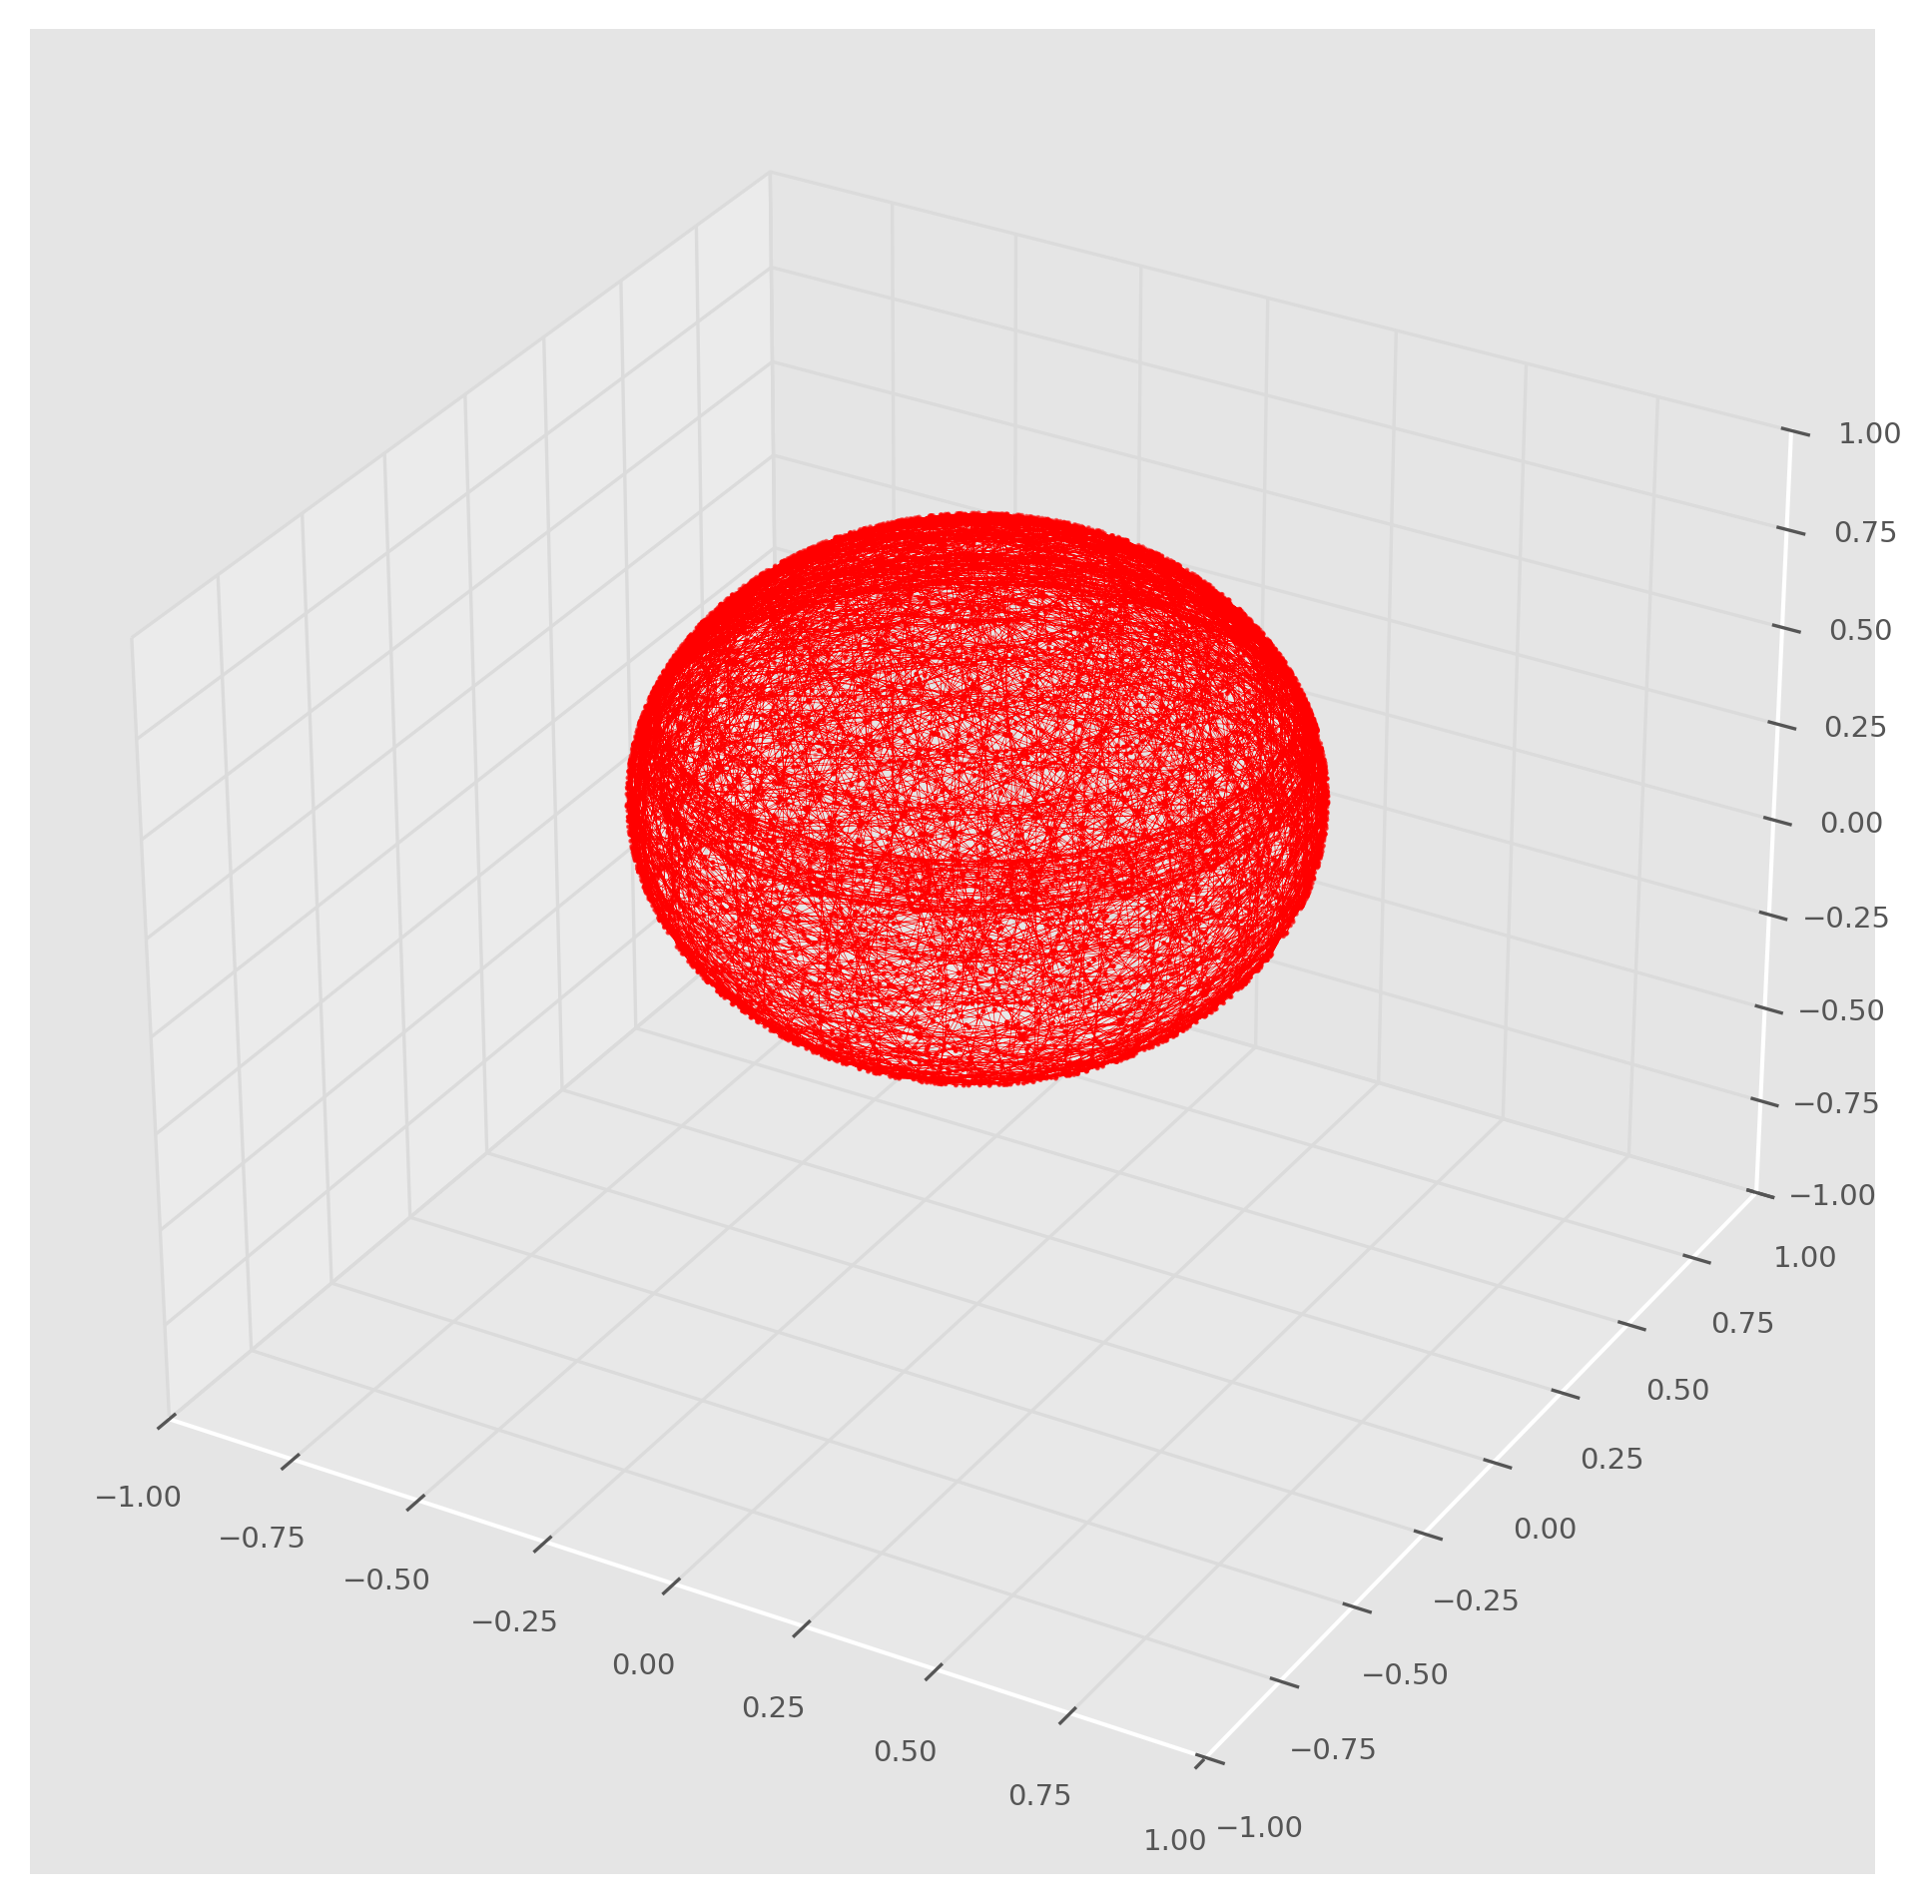

In [23]:
# make 3D workspace

plt.figure(figsize=(8,8),dpi=300)
ax=plt.axes(projection="3d")
ax.plot3D(pose[0],pose[1],pose[2],color='red',linewidth=0.15)
ax.scatter3D(pose[0],pose[1],pose[2],s=0.5,color='red')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()


## Inverse Kinematics

Inverse kinematics determines the joint configuration required to reach a desired end-effector pose:

$$
q = f^{-1}(T)
$$

Where $T$ is the desired transformation matrix.

This problem may have multiple solutions or no solution depending on the target position and robot constraints. A valid solution is selected for trajectory planning.

In [26]:
# Select an end point inside the workspace
# The point is taken from a valid Panda configuration, so it is reachable.
import spatialmath as sm
q_target = [np.pi/4, -np.pi/3, -np.pi/4, -np.pi/2, -np.pi/3, np.pi/4, np.pi/4]

T_target = robot.fkine(q_target)
point = T_target.t

# Use SE3 target transform for inverse kinematics
T_end = sm.SE3.Trans(point)

# Inverse kinematics for position only
ik_solution = robot.ikine_LM(
    T_end,
    q0=q_start,
    mask=[1, 1, 1, 0, 0, 0]
)

print(ik_solution)

# Check the solution
if ik_solution.success:
    q_end = ik_solution.q
    print("Inverse kinematics solution found:")
    print(q_end)
else:
    raise ValueError("Inverse kinematics failed. Choose another target point.")

IKSolution: q=[1.394, -1.429, -0.7809, -1.938, 0.09141, -0.7939, 0], success=True, iterations=8, searches=1, residual=3.25e-09
Inverse kinematics solution found:
[ 1.39447466 -1.42947698 -0.78091258 -1.93767769  0.09140512 -0.79394525
  0.        ]


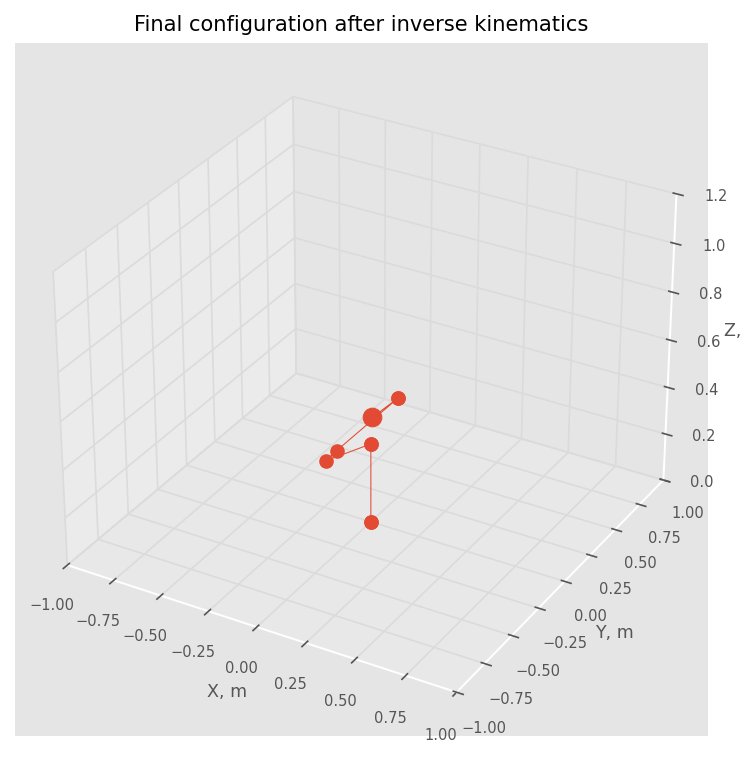

In [29]:
# Manual plot of final robot configuration
T_all = robot.fkine_all(q_end)

xs = [0]
ys = [0]
zs = [0]

for T in T_all:
    xs.append(T.t[0])
    ys.append(T.t[1])
    zs.append(T.t[2])

fig = plt.figure(figsize=(7, 6), dpi=150)
ax = fig.add_subplot(111, projection='3d')

ax.plot(xs, ys, zs, marker='o')
ax.scatter(xs[-1], ys[-1], zs[-1], s=80)

ax.set_title("Final configuration after inverse kinematics")
ax.set_xlabel("X, m")
ax.set_ylabel("Y, m")
ax.set_zlabel("Z, m")

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(0, 1.2)

plt.show()

In [30]:
N=100
#detected time
t_start=0
t_stop=5
t_shag=t_stop/N
time=np.arange(t_start,t_stop,t_shag)
#Ploynominal Trajectory
tr_jtraj=rtb.jtraj(q_start,q_end,time)

In [31]:
# Trapezoidal Velocity Profile
tr_trap=rtb.mtraj(rtb.trapezoidal,q_start,q_end,time)


In [32]:
# Quintic Polynominal
tr_quin=rtb.mtraj(rtb.quintic,q_start,q_end,time)


In [33]:
# Cartesian Straight-Line Trajectory
q_start = np.array(q_start, dtype=float)
q_end = np.array(q_end, dtype=float)

N = len(time)

T_start = robot.fkine(q_start)
T_goal = robot.fkine(q_end)

q_cart = []
success_flags = []
q_guess = q_start.copy()

# Smooth time scaling: s starts and ends with zero velocity
s_profile = rtb.quintic(0, 1, time).q

for s in s_profile:

    T_s = T_start.interp(T_goal, s)

    sol = robot.ikine_GN(T_s, q0=q_guess)

    if sol.success:
        q_new = sol.q

        q_new = np.unwrap(
            np.vstack([q_guess, q_new]),
            axis=0
        )[1]

        q_cart.append(q_new)
        q_guess = q_new.copy()
        success_flags.append(True)

    else:
        q_cart.append(q_guess.copy())
        success_flags.append(False)

q_cart = np.array(q_cart)

dt = time[1] - time[0]
qd_cart = np.gradient(q_cart, dt, axis=0)
qdd_cart = np.gradient(qd_cart, dt, axis=0)

print("Cartesian trajectory shape:", q_cart.shape)
print("IK success rate:", sum(success_flags), "/", N)
print("Cartesian start velocity:", qd_cart[0])
print("Cartesian end velocity:", qd_cart[-1])

Cartesian trajectory shape: (100, 7)
IK success rate: 0 / 100
Cartesian start velocity: [0. 0. 0. 0. 0. 0. 0.]
Cartesian end velocity: [0. 0. 0. 0. 0. 0. 0.]


## Motion Analysis

The motion is analyzed using:

- Position: $q(t)$
- Velocity: $\dot{q}(t)$
- Acceleration: $\ddot{q}(t)$

These metrics describe the kinematic and dynamic behavior of the manipulator during motion.

## Position Analysis

The position plots show that all trajectory methods successfully move the robot from $q_{start}$ to $q_{end}$.

Polynomial-based methods provide smoother transitions, while trapezoidal profiles exhibit linear segments.

The quintic trajectory shows the smoothest behavior near the boundaries.

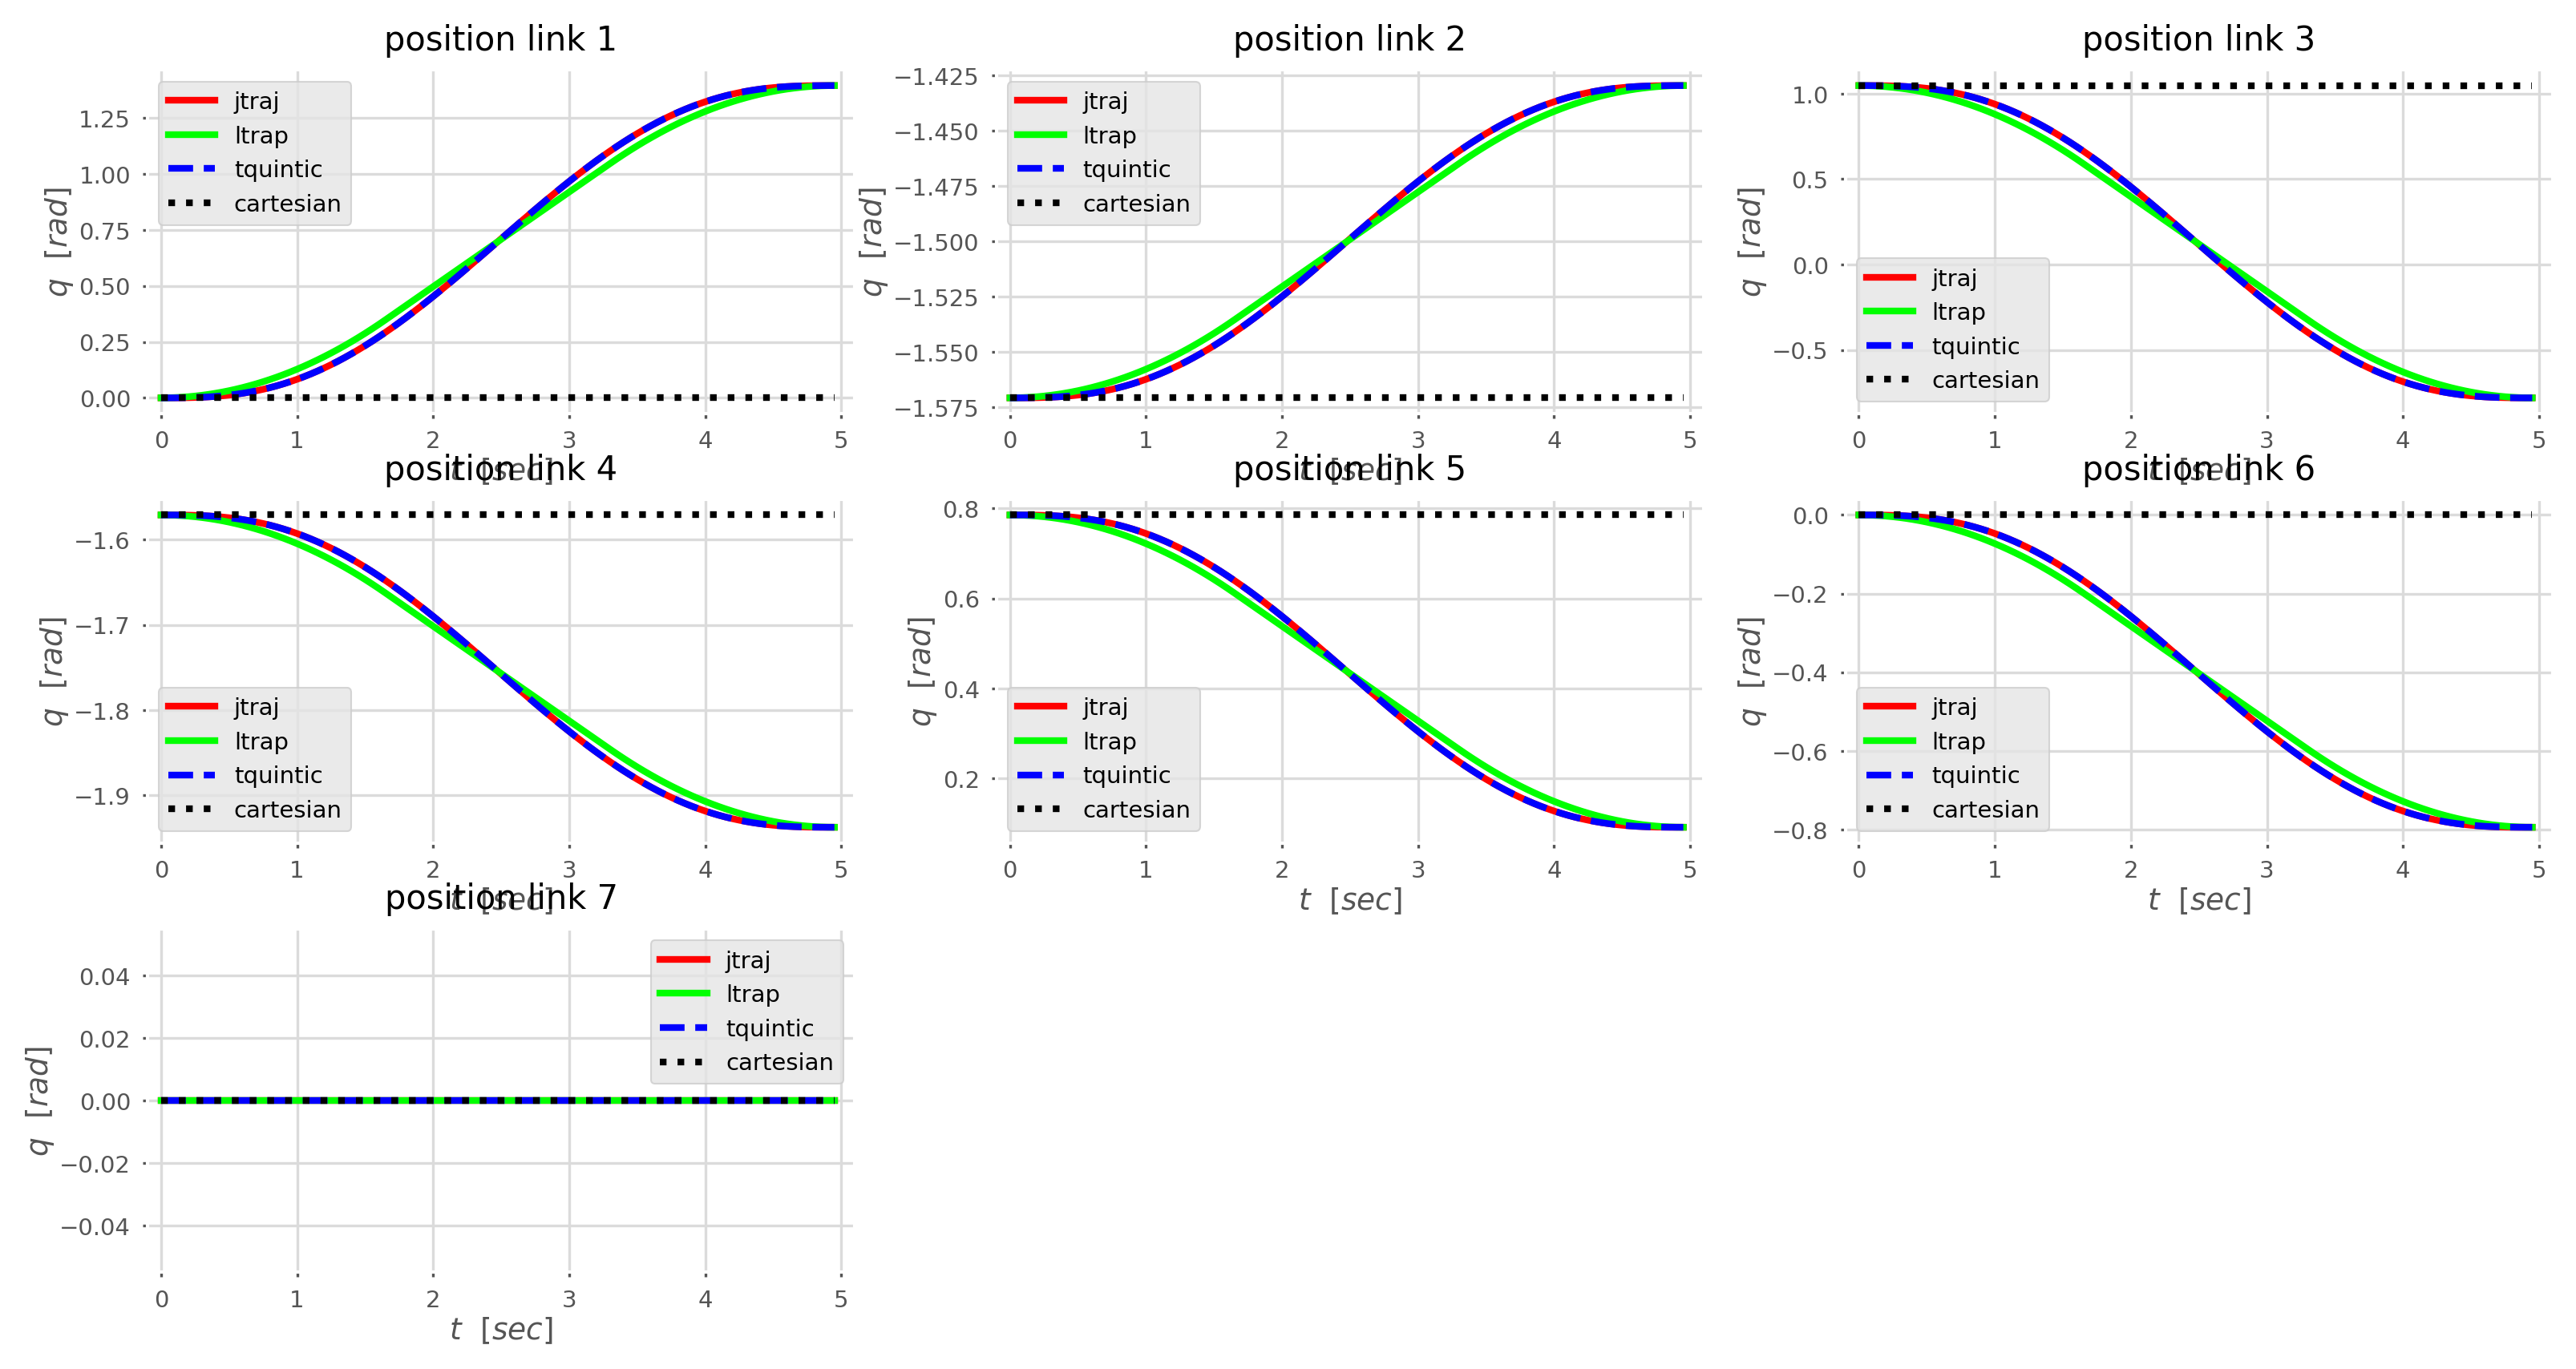

In [34]:
plt.figure(figsize=(10,5), dpi=300)  # Adjuste the plots

for g in range(1,8):
# plot for each link
    plt.subplot(3,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)

    #get the position data from each method
    traektoriya_jtraj = [tr_jtraj.q[i][g-1] for i in range(len(tr_jtraj.q))]
    traektoriya_trap = [tr_trap.q[i][g-1] for i in range(len(tr_trap.q))]
    traektoriya_quin = [tr_quin.q[i][g-1] for i in range(len(tr_quin.q))]
    traektoriya_cart = [q_cart[i][g-1] for i in range(len(q_cart))]

    # plot the position with time
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"ltrap")
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tquintic")
    plt.plot(time, traektoriya_cart, linestyle=':', linewidth=2, color=(0,0,0), label=r"cartesian")

    #adjuste the plot for each link
    plt.title(r"position link {}".format(g), fontsize=10)
    plt.ylabel(r"$q$  [$rad$]", fontsize=9)
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)
    plt.grid(True)
    plt.legend()
    ax = plt.gca()
    ax.set_facecolor((1,1,1))
    ax.set_xlim([t_start-0.1,t_stop+0.1])
plt.show()

## Velocity Analysis

Velocity plots reveal:

- Smooth profiles for polynomial methods
- Piecewise behavior for trapezoidal trajectory
- Continuous and smooth transitions for quintic trajectories
- Cartenis

Smooth velocity reduces mechanical stress on actuators.

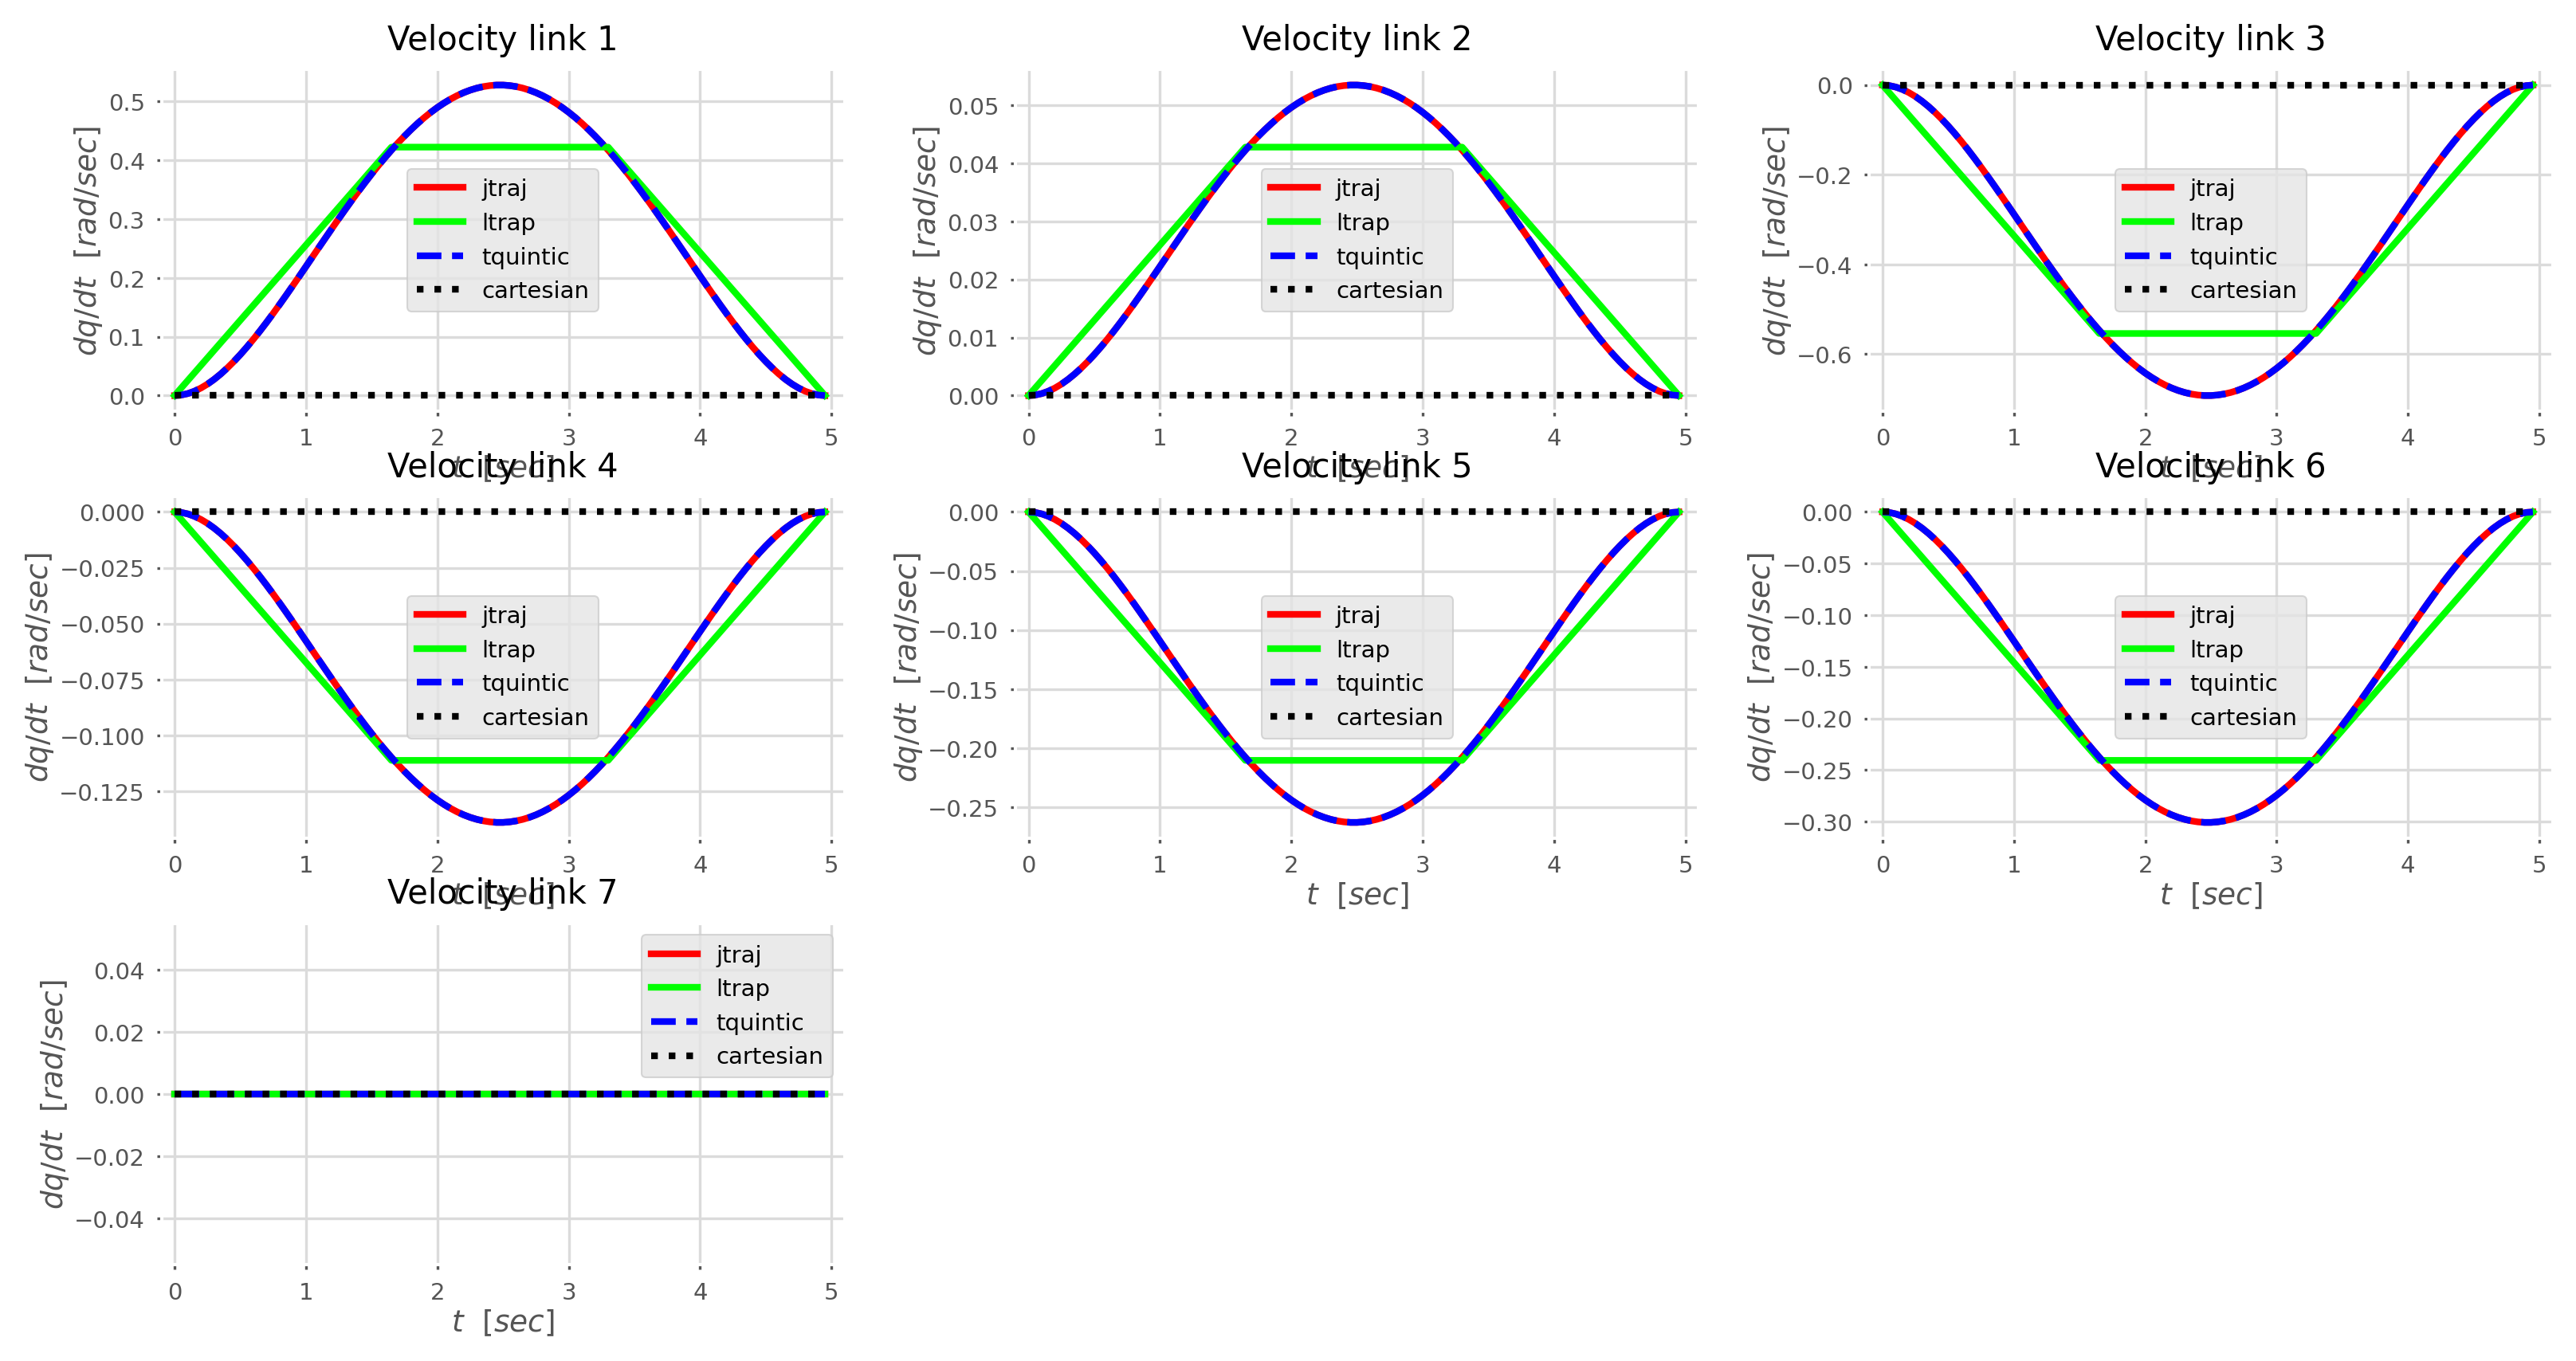

In [35]:
plt.figure(figsize=(10,5), dpi=300)
for g in range(1,8):
    # plot for each link
    plt.subplot(3,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.25, hspace=0.25)

    #get the velocity data from each method
    traektoriya_jtraj = [tr_jtraj.qd[i][g-1] for i in range(len(tr_jtraj.qd))]
    traektoriya_trap = [tr_trap.qd[i][g-1] for i in range(len(tr_trap.qd))]
    traektoriya_quin = [tr_quin.qd[i][g-1] for i in range(len(tr_quin.qd))]
    traektoriya_cart = [qd_cart[i][g-1] for i in range(len(qd_cart))]

    # plot the velocity with time
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"ltrap")
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tquintic")
    plt.plot(time, traektoriya_cart, linestyle=':', linewidth=2, color=(0,0,0), label=r"cartesian")

    #adjuste the plot for each link
    plt.title(r"Velocity link {}".format(g), fontsize=10)
    plt.ylabel(r"$dq/dt$  [$rad/sec$]", fontsize=9)
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)
    plt.grid(True)
    plt.legend()
    ax = plt.gca()
    ax.set_facecolor((1,1,1))
    ax.set_xlim([t_start-0.1,t_stop+0.1])
plt.show()

## Acceleration Analysis

Acceleration plots show:

- Discontinuities in trapezoidal trajectories
- Continuous acceleration in quintic trajectories

Smooth acceleration improves system stability and reduces vibration.

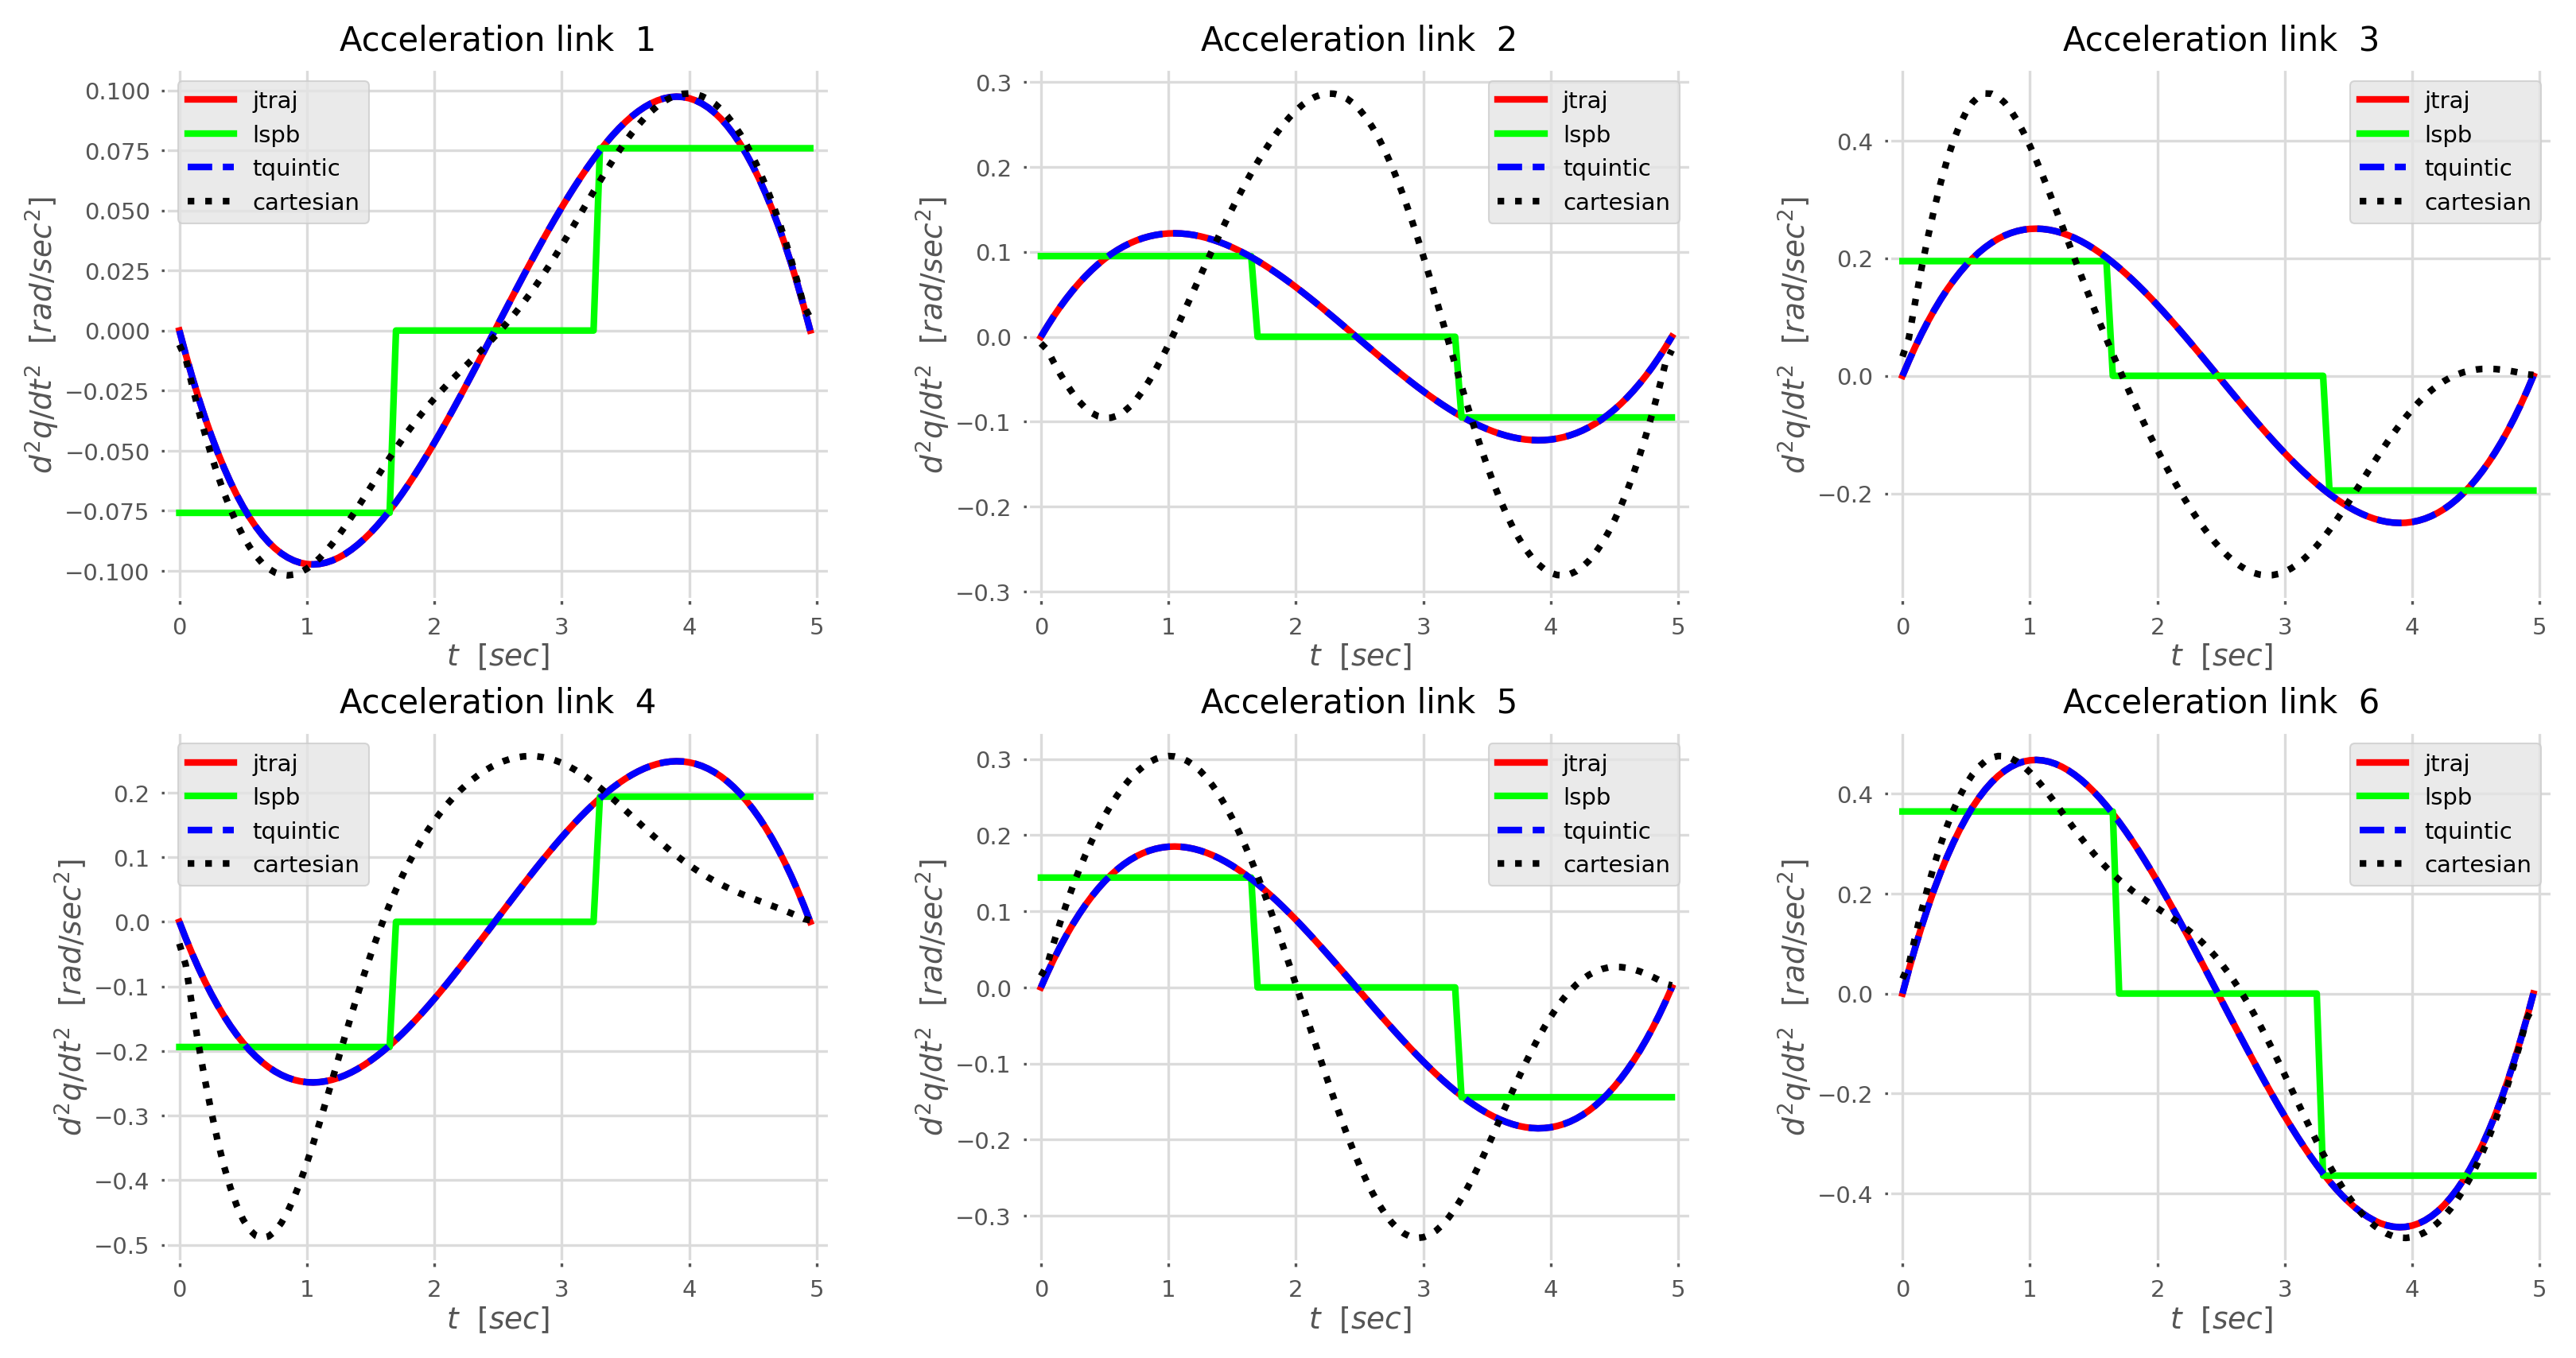

In [ ]:
fig = plt.figure(figsize=(10,5), dpi=300)
for g in range(1,8):
    # plot for each link
    plt.subplot(3,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.3, hspace=0.25)

    #get the acceleration data from each method
    traektoriya_jtraj = [tr_jtraj.qdd[i][g-1] for i in range(len(tr_jtraj.qdd))]
    traektoriya_trap = [tr_trap.qdd[i][g-1] for i in range(len(tr_trap.qdd))]
    traektoriya_quin = [tr_quin.qdd[i][g-1] for i in range(len(tr_quin.qdd))]
    traektoriya_cart = [qdd_cart[i][g-1] for i in range(len(qdd_cart))]

    # plot the acceleration with time
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"trap")
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tquintic")
    plt.plot(time, traektoriya_cart, linestyle=':', linewidth=2, color=(0,0,0), label=r"cartesian")

    #adjuste the plot for each link
    plt.title(r"Acceleration link  {}".format(g), fontsize=10)
    plt.ylabel(r"${d^2}q/d{t^2}$  [$rad/{sec}^2$]", fontsize=9)
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)
    plt.grid(True)
    plt.legend()
    ax = plt.gca()
    ax.set_facecolor((1,1,1))
    ax.set_xlim([t_start-0.1,t_stop+0S.1])
plt.show()

## Comparative Analysis

The implemented trajectory planning methods show different motion characteristics:

- **jtraj** provides convenient joint-space interpolation with smooth position and velocity profiles.
- **Trapezoidal velocity profile** is simple and efficient, but it introduces sharper acceleration changes.
- **Quintic polynomial trajectory** provides the smoothest joint-space motion because it ensures continuous position, velocity, and acceleration.
- **Cartesian straight-line trajectory** controls the end-effector path directly in Cartesian space, but requires solving inverse kinematics at each trajectory point.

This comparison demonstrates a trade-off between joint-space smoothness and Cartesian path accuracy.

# Conclusion

In this laboratory work, the Panda manipulator was successfully modeled and analyzed using the Robotics Toolbox for Python.

The robot model was loaded, and the required kinematic and dynamic parameters were defined. An arbitrary initial joint configuration was selected, and forward kinematics was used to compute the initial end-effector pose.

The workspace was approximated by sampling the first three joint limits. A target point was selected inside the workspace, and inverse kinematics was successfully solved to obtain the final joint configuration.

Four trajectory planning methods were implemented and compared: jtraj, trapezoidal velocity profile, quintic polynomial trajectory, and Cartesian straight-line trajectory. Position, velocity, and acceleration plots were generated for all seven joints.

The results show that the quintic trajectory provides the smoothest joint-space motion, while the trapezoidal method is simpler but produces sharper acceleration transitions. The Cartesian method provides better control over the end-effector path, but it requires solving inverse kinematics along the trajectory.

Overall, the lab demonstrates that trajectory planning is not only about reaching the target point, but also about selecting a motion profile that satisfies smoothness, stability, and geometric requirements.